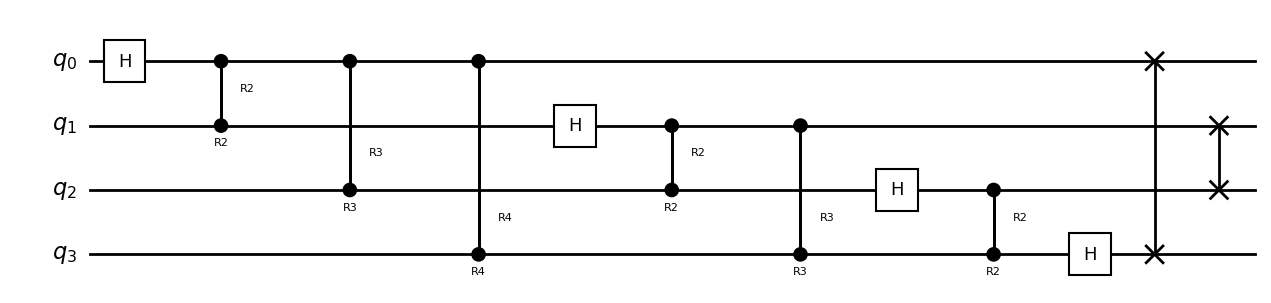

In [11]:
from qiskit import QuantumCircuit
import numpy as np
import re

def build_qft(n):
    """Build an n-qubit Quantum Fourier Transform circuit."""
    qc = QuantumCircuit(n)
    
    for t in range(n):  # Process each qubit as target
        qc.h(t)  # Hadamard: put target into superposition
        
        for c in range(t + 1, n):  # Controlled rotations from qubits below
            k = c - t + 1  # Rotation index: R2, R3, R4...
            angle = np.pi / (2**(k-1))  # Angle: pi/2 for R2, pi/4 for R3, etc.
            qc.cp(angle, c, t, label='R' + str(k))  # Controlled phase gate
        
        qc.barrier()  # Prevents visual reordering of gates in diagram
    
    # Swap qubits to correct the reversed bit order of QFT output
    qc.swap(0,3)
    qc.swap(1,2)
    
    return qc

def relabel(fig):
    """Replace Qiskit's default 'P(pi/x)' labels with 'Rk' notation."""
    ax = fig.axes[0]  # Get the drawing canvas
    
    for text_obj in ax.texts:
        content = text_obj.get_text()
        
        if content.startswith('P ('):  # Find phase gate labels on target side
            m = re.search(r'/(\d+)', content)  # Extract denominator (e.g. 4 from "P(pi/4)")
            if m:
                denom = int(m.group(1))
                k = int(np.log2(denom)) + 1  # Convert back to Rk index
                text_obj.set_text('R' + str(k))  # Replace with Rk label
    
    return fig

# Build and draw the 4-qubit QFT circuit
qc = build_qft(4)
fig = qc.draw(
    output='mpl',           # Render as matplotlib image
    fold=-1,                # Don't wrap to multiple lines
    style={'name': 'bw'},   # Black and white for report
    plot_barriers=False      # Hide barrier lines from diagram
)
relabel(fig)  # Fix gate labels to Rk notation